<a href="https://colab.research.google.com/github/tudy0406/AI-Goolge-Colab/blob/main/Is_lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD

In [22]:
car_model = DiscreteBayesianNetwork([
    ("Battery", "Starter"),
    ("Starter", "EngineTurnsOver"),
    ("EngineTurnsOver", "CarStarts"),
    ("Fuel", "CarStarts")
])

In [23]:
cpd_battery = TabularCPD(
    variable="Battery",
    variable_card=2,
    values=[[0.1], [0.9]],
    state_names={"Battery": ["Bad", "Good"]}
)

cpd_fuel = TabularCPD(
    variable="Fuel",
    variable_card=2,
    values=[[0.1], [0.9]],
    state_names={"Fuel": ["Empty", "Full"]}
)

cpd_starter = TabularCPD(
    variable="Starter",
    variable_card=2,
    values=[
        [0.9, 0.1],   # Starter fails
        [0.1, 0.9]    # Starter works
    ],
    evidence=["Battery"],
    evidence_card=[2],
    state_names={
        "Starter": ["Fail", "Works"],
        "Battery": ["Bad", "Good"]
    }
)

cpd_engine = TabularCPD(
    variable="EngineTurnsOver",
    variable_card=2,
    values=[
        [0.95, 0.2],
        [0.05, 0.8]
    ],
    evidence=["Starter"],
    evidence_card=[2],
    state_names={
        "EngineTurnsOver": ["No", "Yes"],
        "Starter": ["Fail", "Works"]
    }
)

cpd_start = TabularCPD(
    variable="CarStarts",
    variable_card=2,
    values=[
        [0.99, 0.7, 0.6, 0.01],
        [0.01, 0.3, 0.4, 0.99]
    ],
    evidence=["EngineTurnsOver", "Fuel"],
    evidence_card=[2, 2],
    state_names={
        "CarStarts": ["No", "Yes"],
        "EngineTurnsOver": ["No", "Yes"],
        "Fuel": ["Empty", "Full"]
    }
)

In [24]:
car_model.add_cpds(
    cpd_battery,
    cpd_fuel,
    cpd_starter,
    cpd_engine,
    cpd_start
)

In [25]:
car_model.check_model()

True

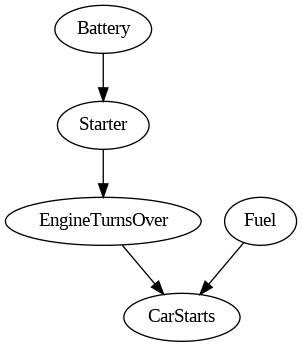

In [26]:
from IPython.display import Image

vinet = car_model.to_graphviz()
vinet.draw('is03_car_model.png', prog='dot')
Image('is03_car_model.png')

In [27]:
import pprint

# Access attributes of the model
nodes = car_model.nodes()
edges = car_model.edges()
cpds = car_model.get_cpds()

print(f"Nodes in the model: {nodes} \n")
print(f"Edges in the model: {edges} \n")
print(f"CPDs in the model: ")

pprint.pp(cpds)

Nodes in the model: ['Battery', 'Starter', 'EngineTurnsOver', 'CarStarts', 'Fuel'] 

Edges in the model: [('Battery', 'Starter'), ('Starter', 'EngineTurnsOver'), ('EngineTurnsOver', 'CarStarts'), ('Fuel', 'CarStarts')] 

CPDs in the model: 
[<TabularCPD representing P(Battery:2) at 0x784791260470>,
 <TabularCPD representing P(Fuel:2) at 0x7847912608c0>,
 <TabularCPD representing P(Starter:2 | Battery:2) at 0x7847911a6960>,
 <TabularCPD representing P(EngineTurnsOver:2 | Starter:2) at 0x7847911eba40>,
 <TabularCPD representing P(CarStarts:2 | EngineTurnsOver:2, Fuel:2) at 0x7847c6260590>]


In [28]:
print (cpd_battery)

+---------------+-----+
| Battery(Bad)  | 0.1 |
+---------------+-----+
| Battery(Good) | 0.9 |
+---------------+-----+


In [29]:
print (cpd_fuel)
print (cpd_starter)
print (cpd_engine)
print (cpd_start)


+-------------+-----+
| Fuel(Empty) | 0.1 |
+-------------+-----+
| Fuel(Full)  | 0.9 |
+-------------+-----+
+----------------+--------------+---------------+
| Battery        | Battery(Bad) | Battery(Good) |
+----------------+--------------+---------------+
| Starter(Fail)  | 0.9          | 0.1           |
+----------------+--------------+---------------+
| Starter(Works) | 0.1          | 0.9           |
+----------------+--------------+---------------+
+----------------------+---------------+----------------+
| Starter              | Starter(Fail) | Starter(Works) |
+----------------------+---------------+----------------+
| EngineTurnsOver(No)  | 0.95          | 0.2            |
+----------------------+---------------+----------------+
| EngineTurnsOver(Yes) | 0.05          | 0.8            |
+----------------------+---------------+----------------+
+-----------------+-----+----------------------+
| EngineTurnsOver | ... | EngineTurnsOver(Yes) |
+-----------------+-----+-----------